# Praktikum Pengolahan Citra Digital
## Histogram Stretching

Notebook ini berisi program histogram stretching pada citra grayscale serta visualisasi histogram sebelum dan sesudah proses.

In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

### Membaca Citra Grayscale

In [2]:
img = cv.imread('low.jpeg', 0)

### Menghitung Histogram dan CDF

In [3]:
hist, bins = np.histogram(img.flatten(), 256, [0,256])
cdf = hist.cumsum()

### Proses Histogram Stretching

In [4]:
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
cdf = np.ma.filled(cdf_m, 0).astype('uint8')

img2 = cdf[img]

### Normalisasi CDF untuk Visualisasi

In [5]:
cdf_normalized = cdf * float(hist.max()) / cdf.max()

### Histogram Sebelum dan Sesudah Stretching

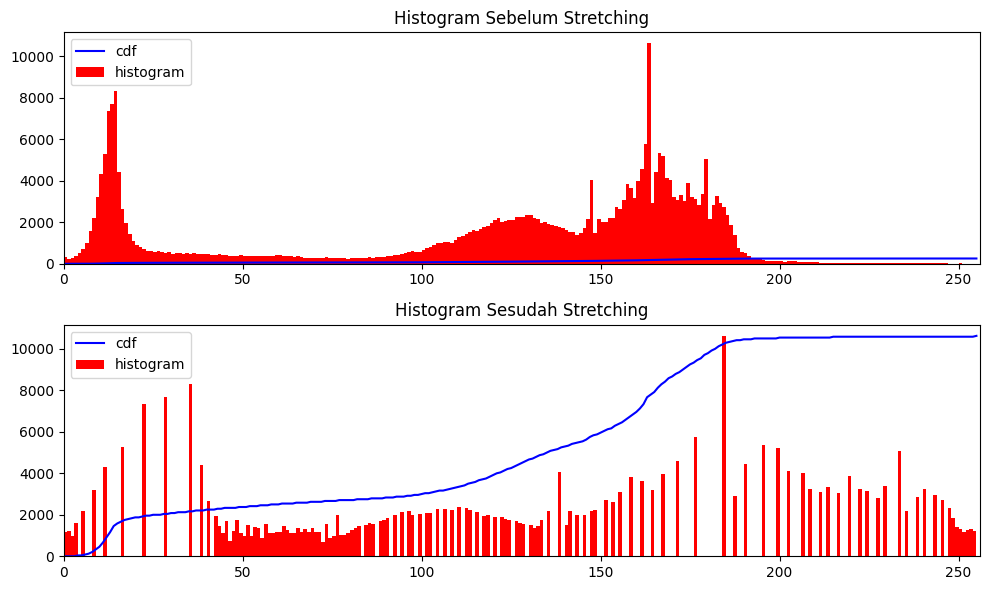

In [6]:
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(cdf, color='b')
plt.hist(img.flatten(), 256, [0,256], color='r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc='upper left')
plt.title('Histogram Sebelum Stretching')

plt.subplot(2,1,2)
plt.plot(cdf_normalized, color='b')
plt.hist(img2.flatten(), 256, [0,256], color='r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc='upper left')
plt.title('Histogram Sesudah Stretching')

plt.tight_layout()
plt.show()

### Menampilkan Hasil Citra

In [ ]:
cv.imshow('Citra Asli', img)
cv.imshow('Citra Setelah Histogram Stretching', img2)
cv.waitKey(0)
cv.destroyAllWindows()